# VRP Backtest — Iteration 4: Robustness

Stress-tests of the deployed macro short-vol **WINNER** (SPX bull put spread, Δ0.25/0.125,
~30 trading-day hold, weekly entry, ramp+ vrp-z sizing) along five axes, each benchmarked
against the **iteration-3 SPX base case** and **SPY buy-and-hold**.

Data: SPX+VIX (`vol_index_daily`, 2006→), SPY spot (lake). Reproduce:
`uv run python scripts/research/vrp_robustness_run.py` (SEED=20260623); full traces in
`docs/research/vrp/iter4-*.csv`.

**Account sizing.** The smallest capital to *start* trading in 2007 is ~\$10k, but SPX spread
max-loss rises ~15× to 2026, so the experiments use the **trade-throughout** account
(~\$143k at 20%-risk/spread) — the start-floor goes dormant by 2015.


In [1]:
import csv
import pathlib

import matplotlib.pyplot as plt

DATA = next(p for p in [pathlib.Path("docs/research/vrp"), pathlib.Path(".")]
            if (p / "iter4-mc.csv").exists())


def load(name):
    with (DATA / name).open() as fh:
        return list(csv.DictReader(fh))


def f(x):
    """CSV cell -> float or nan (blank/None -> nan)."""
    try:
        return float(x)
    except (TypeError, ValueError):
        return float("nan")


ep = load("iter4-extra-position.csv")
wd = load("iter4-weekday.csv")
bs = load("iter4-bear-start.csv")
bpath = load("iter4-bear-start-path.csv")
mc = load("iter4-mc.csv")
mct = load("iter4-mc-trials.csv")
mincap = load("iter4-min-capital.csv")

BASE = next(r for r in ep if r["variant"] == "baseline_iter3_spx")
SPY = next(r for r in ep if r["variant"] == "baseline_spy_buyhold")
BASE_SH, SPY_SH = f(BASE["sharpe"]), f(SPY["sharpe"])
print(f"iteration-3 SPX base Sharpe={BASE_SH:.3f}  |  SPY buy-hold Sharpe={SPY_SH:.3f}")


iteration-3 SPX base Sharpe=1.680  |  SPY buy-hold Sharpe=0.620


## §1 Extra position (overlay vs staggered, comp + non-comp)

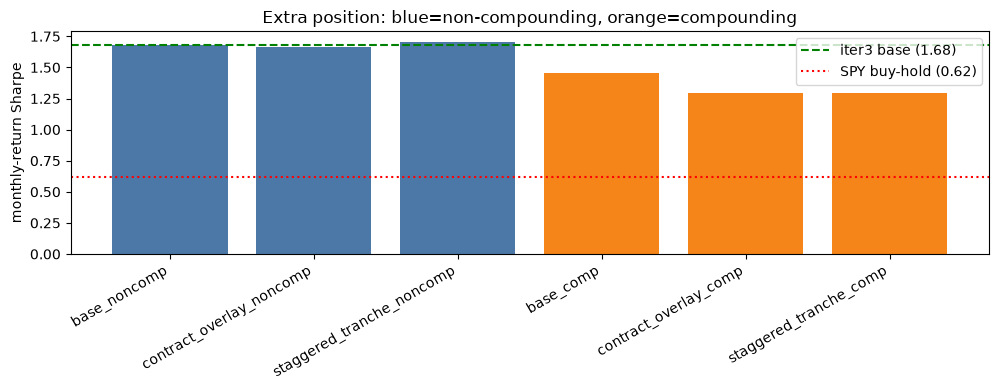

base_noncomp                 sharpe= 1.680  cagr=  0.136  maxdd_pct=   -0.90  util_peak=   1.00  n=470
contract_overlay_noncomp     sharpe= 1.668  cagr=  0.143  maxdd_pct=   -1.17  util_peak=   1.00  n=448
staggered_tranche_noncomp    sharpe= 1.705  cagr=  0.143  maxdd_pct=   -1.18  util_peak=   1.00  n=518
base_comp                    sharpe= 1.457  cagr=  0.570  maxdd_pct= -981.13  util_peak=4662.97  n=508
contract_overlay_comp        sharpe= 1.297  cagr=  0.533  maxdd_pct=-1239.05  util_peak=2986.95  n=479
staggered_tranche_comp       sharpe= 1.294  cagr=  0.505  maxdd_pct= -873.33  util_peak=2106.37  n=537


In [2]:
# §1 Extra position — Sharpe by variant vs the two baselines
order = ["base_noncomp", "contract_overlay_noncomp", "staggered_tranche_noncomp",
         "base_comp", "contract_overlay_comp", "staggered_tranche_comp"]
rows = {r["variant"]: r for r in ep}
vals = [f(rows[v]["sharpe"]) for v in order]
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#4c78a8"] * 3 + ["#f58518"] * 3
ax.bar(range(len(order)), vals, color=colors)
ax.axhline(BASE_SH, color="green", ls="--", label=f"iter3 base ({BASE_SH:.2f})")
ax.axhline(SPY_SH, color="red", ls=":", label=f"SPY buy-hold ({SPY_SH:.2f})")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("monthly-return Sharpe")
ax.set_title("Extra position: blue=non-compounding, orange=compounding")
ax.legend()
plt.tight_layout()
plt.show()
for v in order:
    r = rows[v]
    cagr = f(r["cagr"]) if r["cagr"] else f(r["cagr_excess"])
    print(f"{v:28s} sharpe={f(r['sharpe']):6.3f}  cagr={cagr:7.3f}  "
          f"maxdd_pct={f(r['maxdd_pct']):8.2f}  util_peak={f(r['util_peak']):7.2f}  n={r['n_rungs']}")


## §2 Entry weekday

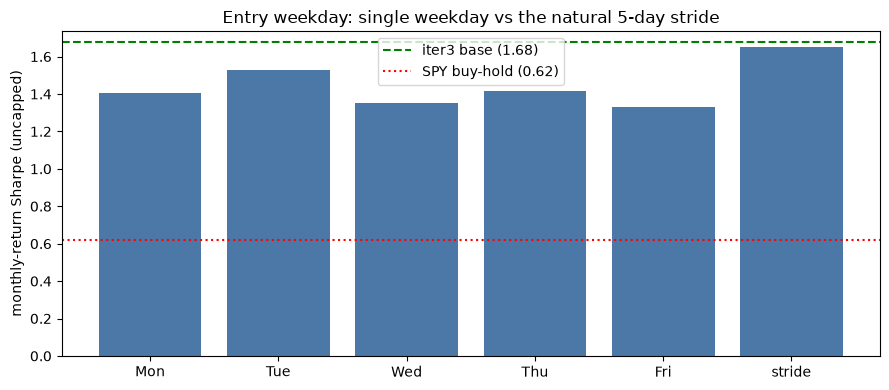

In [3]:
# §2 Entry weekday — does the day matter? (uncapped clean-signal basis)
labels = ["weekday_0", "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_stride"]
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "stride"]
unc = {r["variant"].replace("_uncapped", ""): r for r in wd if r["basis"] == "uncapped"}
vals = [f(unc[lab]["sharpe"]) for lab in labels]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(days, vals, color="#4c78a8")
ax.axhline(BASE_SH, color="green", ls="--", label=f"iter3 base ({BASE_SH:.2f})")
ax.axhline(SPY_SH, color="red", ls=":", label=f"SPY buy-hold ({SPY_SH:.2f})")
ax.set_ylabel("monthly-return Sharpe (uncapped)")
ax.set_title("Entry weekday: single weekday vs the natural 5-day stride")
ax.legend()
plt.tight_layout()
plt.show()


## §3 Bear-market start

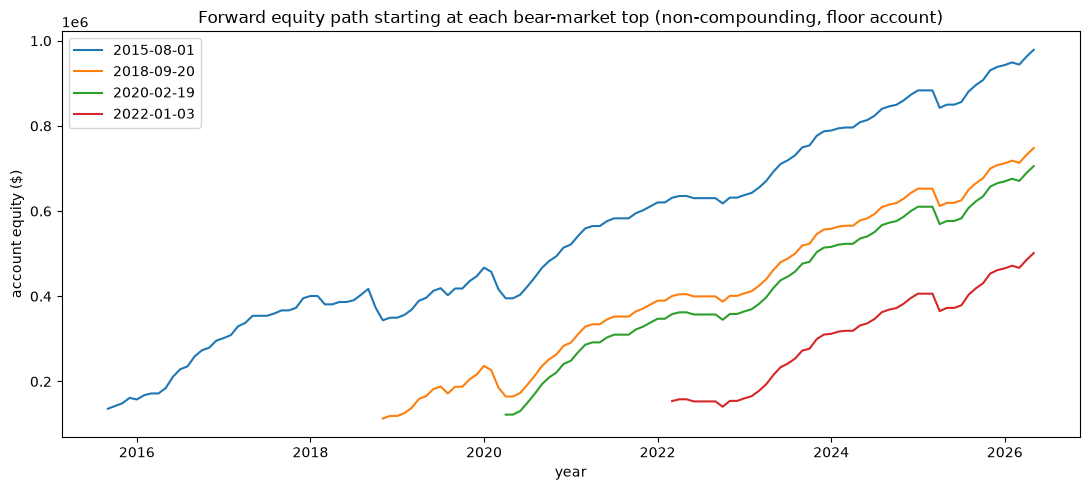

forward returns from each bear start:
  bear_2015-08-01        sharpe= 1.870  6m= +0.17  12m= +0.65  36m= +1.82
  bear_2018-09-20        sharpe= 1.923  6m= +0.11  12m= +0.31  36m= +1.55
  bear_2020-02-19        sharpe= 2.579  6m= +0.35  12m= +1.00  36m= +1.67
  bear_2022-01-03        sharpe= 2.345  6m= +0.07  12m= +0.16  36m= +1.84


In [4]:
# §3 Bear-market start — full equity path from each bear top
starts = sorted({r["start"] for r in bpath})
fig, ax = plt.subplots(figsize=(11, 5))
for st in starts:
    pts = [r for r in bpath if r["start"] == st]
    x = [int(r["year"]) + (int(r["month"]) - 1) / 12 for r in pts]
    y = [f(r["equity"]) for r in pts]
    ax.plot(x, y, label=st)
ax.set_xlabel("year")
ax.set_ylabel("account equity ($)")
ax.set_title("Forward equity path starting at each bear-market top (non-compounding, floor account)")
ax.legend()
plt.tight_layout()
plt.show()
print("forward returns from each bear start:")
for r in bs:
    if r["variant"].startswith("bear_"):
        print(f"  {r['variant']:22s} sharpe={f(r['sharpe']):6.3f}  "
              f"6m={f(r['ret_6m']):+6.2f}  12m={f(r['ret_12m']):+6.2f}  36m={f(r['ret_36m']):+6.2f}")


## §4 Monte-Carlo robustness

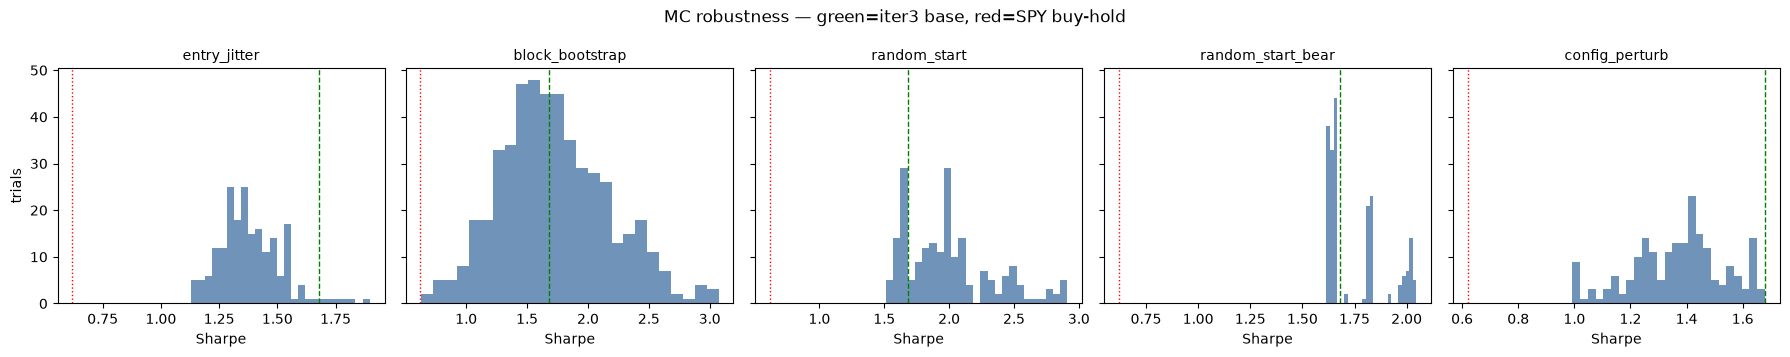

driver       mean    p5     p95   (baseline iter3 = 1.680, SPY = 0.620)
  entry_jitter         1.385  1.194  1.597
  block_bootstrap      1.721  1.050  2.537
  random_start         2.000  1.604  2.727
  random_start_bear    1.750  1.618  2.020
  config_perturb       1.371  1.051  1.643


In [5]:
# §4 Monte-Carlo — trial distributions vs the two baseline Sharpes
tests = ["entry_jitter", "block_bootstrap", "random_start", "random_start_bear", "config_perturb"]
fig, axes = plt.subplots(1, len(tests), figsize=(18, 3.6), sharey=True)
for ax, test in zip(axes, tests):
    vals = [f(r["value"]) for r in mct if r["test"] == test]
    vals = [v for v in vals if v == v]  # drop nan
    ax.hist(vals, bins=25, color="#4c78a8", alpha=0.8)
    ax.axvline(BASE_SH, color="green", ls="--", lw=1)
    ax.axvline(SPY_SH, color="red", ls=":", lw=1)
    ax.set_title(test, fontsize=10)
    ax.set_xlabel("Sharpe")
axes[0].set_ylabel("trials")
fig.suptitle("MC robustness — green=iter3 base, red=SPY buy-hold")
plt.tight_layout()
plt.show()
print("driver       mean    p5     p95   (baseline iter3 = %.3f, SPY = %.3f)" % (BASE_SH, SPY_SH))
for r in mc:
    if r["test"] in tests:
        print(f"  {r['test']:20s} {f(r['mean']):.3f}  {f(r['p5']):.3f}  {f(r['p95']):.3f}")


## §5 Look-ahead audit

The entry decision uses only information available at the close of the entry day:
- **`vrp_z`** — z-score of VRP over the *trailing* 252 days.
- **`rv`** — realized vol over the *trailing* 20 days.
- **IV** — the *contemporaneous* VIX close.
- **Settlement** walks the realized forward path, but that is the *outcome* of a decision
  already made — not an input to it.

The only forward-looking risk is **in-sample config selection** (the WINNER knobs were tuned
on SPX). The MC **config-perturbation** driver quantifies it: perturbing short_delta / hold /
ramp_full_z keeps Sharpe above ~1.0 at p5, so the result is not a knife-edge overfit.

**Caveat — compounding `util_peak` > 1:** for compounding rows `util_peak` is deployed margin
÷ *initial* capital, so it exceeds 1.0 as equity grows. Read it as leverage-vs-start, not a
cap breach.
